# Router-Expert Alignment Analysis

This notebook analyzes alignment between router vectors and expert weight matrices.

**Sections:**
1. Load and explore results
2. Summary visualization
3. Expert-level analysis
4. Full comprehensive analysis
5. Compare multiple layers

## Setup

In [1]:
%matplotlib inline
import pandas as pd
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

from src.alignment_analysis import (
    # Results management
    ResultsManager,
    load_results,
    compare_runs,
    
    # Plotting
    plot_summary,
    plot_expert_analysis,
    plot_full_analysis,
    plot_comparison,
    plot_alignment_vs_k,
    plot_zscore_vs_k,
    plot_cos_squared_per_expert,
    get_summary_columns,
)

## 1. Load Results

List available result files and load one for analysis.

In [2]:
# List available result files
manager = ResultsManager()
result_files = manager.list_results()

print(f"Found {len(result_files)} result files:")
for f in result_files[:10]:  # Show first 10
    print(f"  - {f.name}")

Found 39 result files:
  - layer31_svd_k1-4096-13_shuffles200_seed42_20260207_152047.json
  - layer30_svd_k1-4096-13_shuffles200_seed42_20260207_152034.json
  - layer29_svd_k1-4096-13_shuffles200_seed42_20260207_152022.json
  - layer28_svd_k1-4096-13_shuffles200_seed42_20260207_152010.json
  - layer27_svd_k1-4096-13_shuffles200_seed42_20260207_151959.json
  - layer26_svd_k1-4096-13_shuffles200_seed42_20260207_151946.json
  - layer25_svd_k1-4096-13_shuffles200_seed42_20260207_151935.json
  - layer24_svd_k1-4096-13_shuffles200_seed42_20260207_151922.json
  - layer23_svd_k1-4096-13_shuffles200_seed42_20260207_151910.json
  - layer22_svd_k1-4096-13_shuffles200_seed42_20260207_151858.json


In [30]:
# Load the most recent result file
# Or specify a specific file: result_file = "layer5_svd_....json"
result_file = str(result_files[11]) if result_files else None

if result_file:
    metadata, results = load_results(result_file)
    df = pd.DataFrame([r.__dict__ for r in results])
    
    print(f"Loaded: {result_file}")
    print(f"\nMetadata:")
    print(f"  Model: {metadata.model_id}")
    print(f"  Layer: {metadata.layer}")
    print(f"  Method: {metadata.method}")
    print(f"  K values: {metadata.k_list}")
    print(f"  Shuffles: {metadata.n_shuffles}")
    print(f"  Experts: {metadata.n_experts}")
else:
    print("No result files found. Run an analysis first.")

Loaded: /Users/noyah/University/ILLM project/GaleMoE/results/layer20_svd_k1-4096-13_shuffles200_seed42_20260207_151834.json

Metadata:
  Model: mistralai/Mixtral-8x7B-v0.1
  Layer: 20
  Method: svd
  K values: [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096]
  Shuffles: 200
  Experts: 8


In [31]:
# Summary statistics
if result_file:
    summary_cols = get_summary_columns(df)
    print("Summary (averaged across experts):")
    display(df.groupby("k")[summary_cols].mean())

Summary (averaged across experts):


,align,delta_vs_shuffle,z_vs_shuffle,effect_over_random,cos_squared
k,,,,,
1,0.014862,0.012305,1.854232,0.014618,0.014862
2,0.116924,0.100246,2.436307,0.116436,0.000000
4,0.231420,0.198207,2.659010,0.230443,0.000000
8,0.287510,0.247387,2.802260,0.285557,0.000000
16,0.307513,0.254374,2.542033,0.303606,0.000000
32,0.328186,0.266257,2.527214,0.320374,0.000000
64,0.353050,0.278923,2.538918,0.337425,0.000000
128,0.383151,0.294709,2.733225,0.351901,0.000000
256,0.420942,0.296048,2.624391,0.358442,0.000000


## 2. Summary Visualization

Quick overview of key alignment metrics.

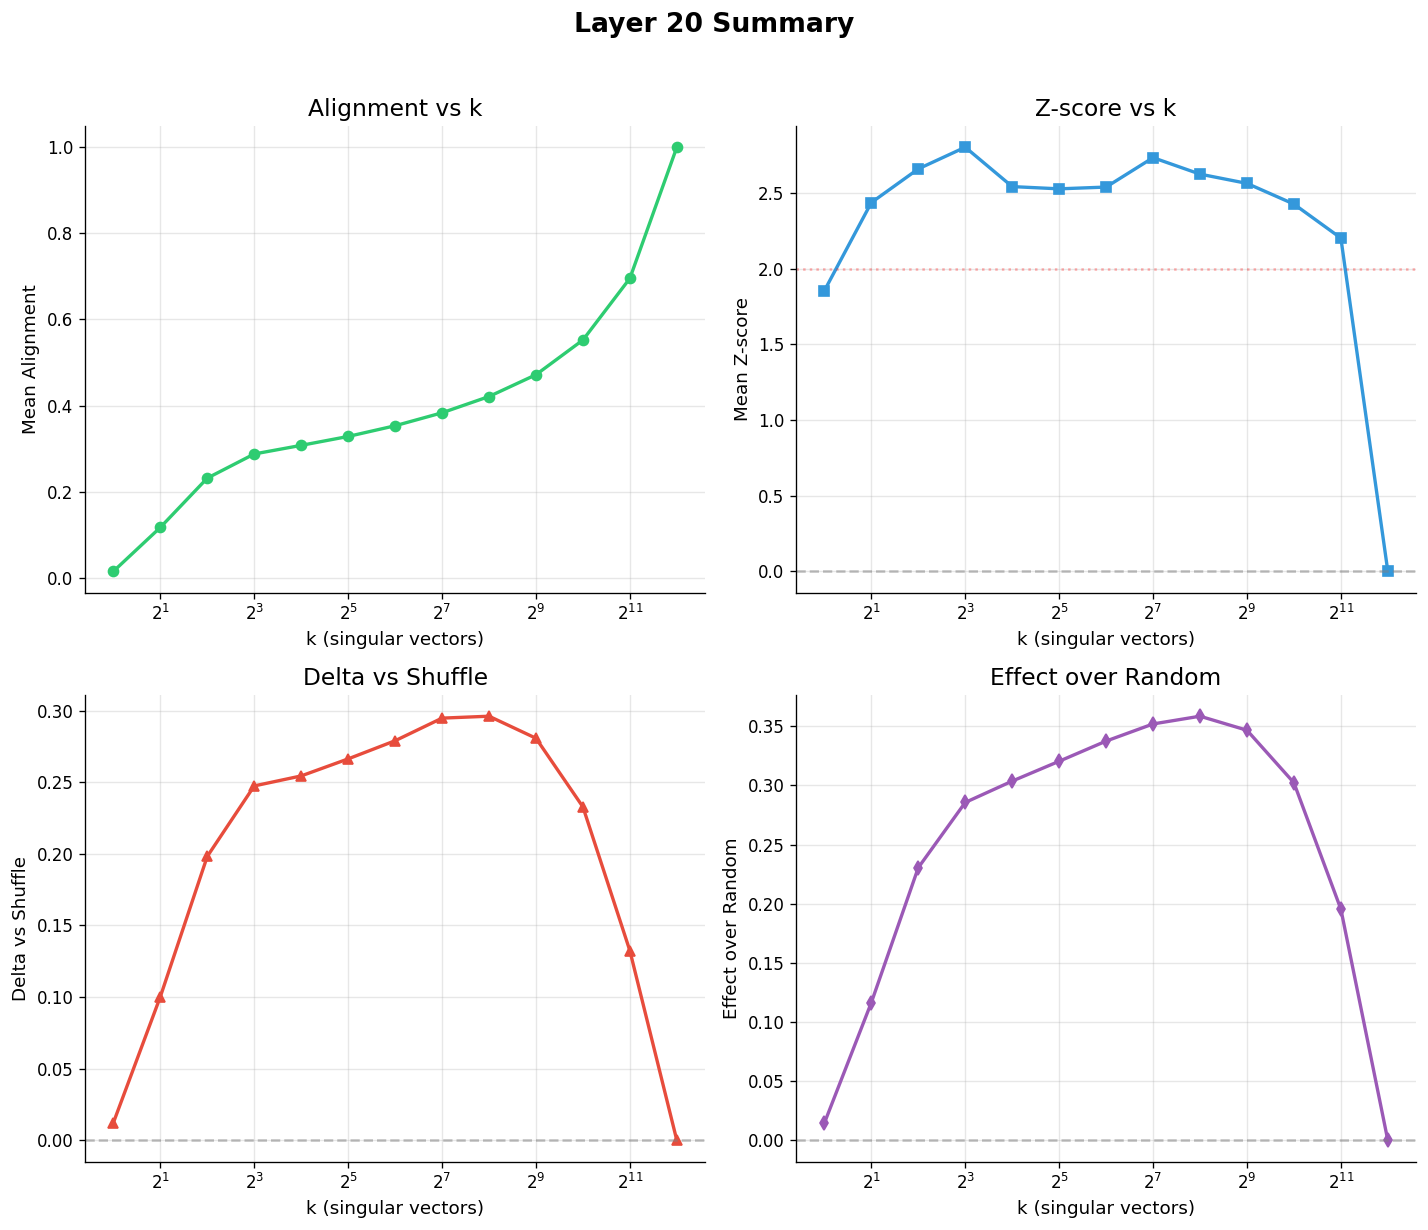

In [32]:
# 2x2 summary plot: alignment, z-score, delta, effect
if result_file:
    plot_summary(results, title=f"Layer {metadata.layer} Summary")

## 3. Expert-Level Analysis

Detailed breakdown by expert with heatmaps and per-expert statistics.

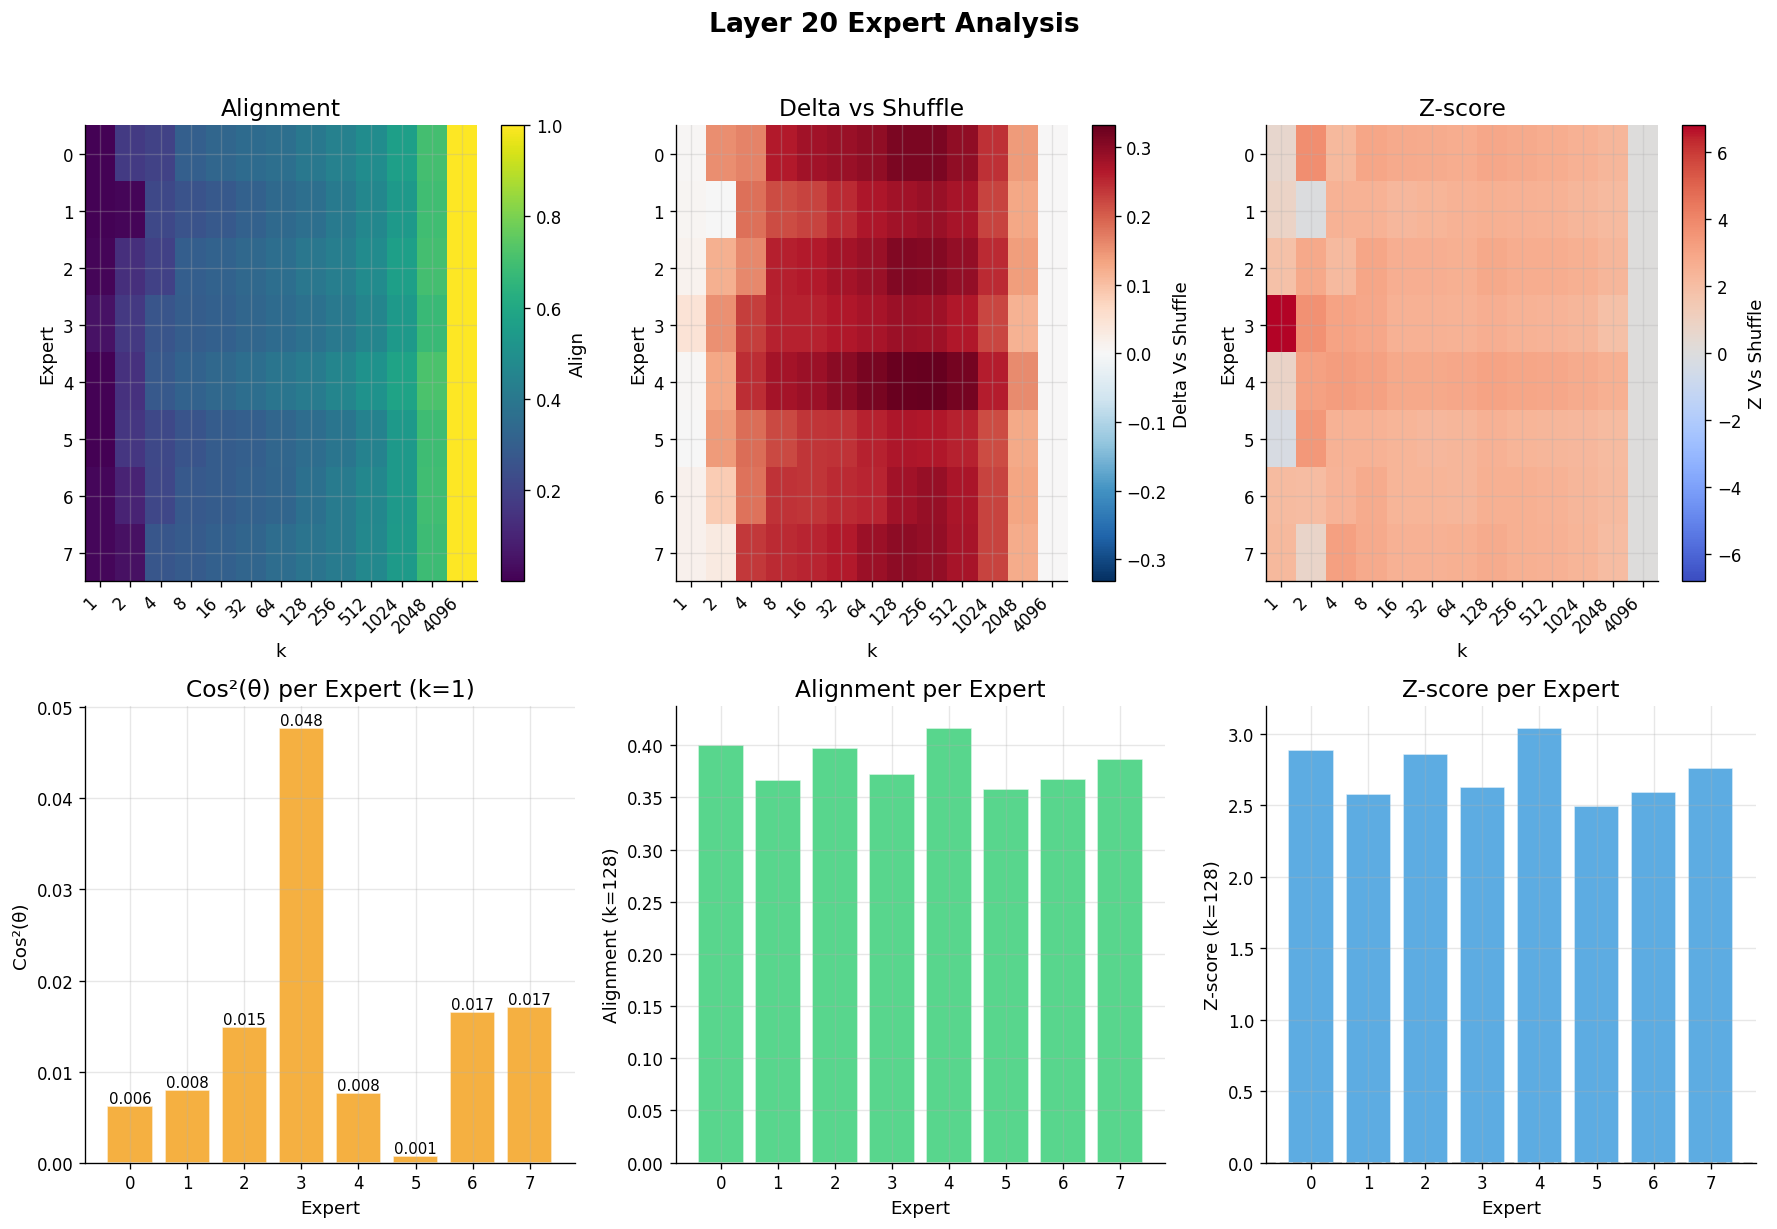

In [33]:
# Expert analysis: heatmaps + per-expert bars
if result_file:
    plot_expert_analysis(results, title=f"Layer {metadata.layer} Expert Analysis")

## 4. Full Comprehensive Analysis

All metrics in a single comprehensive figure.

/Users/noyah/University/ILLM project/GaleMoE/src/alignment_analysis/plots.py:128: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


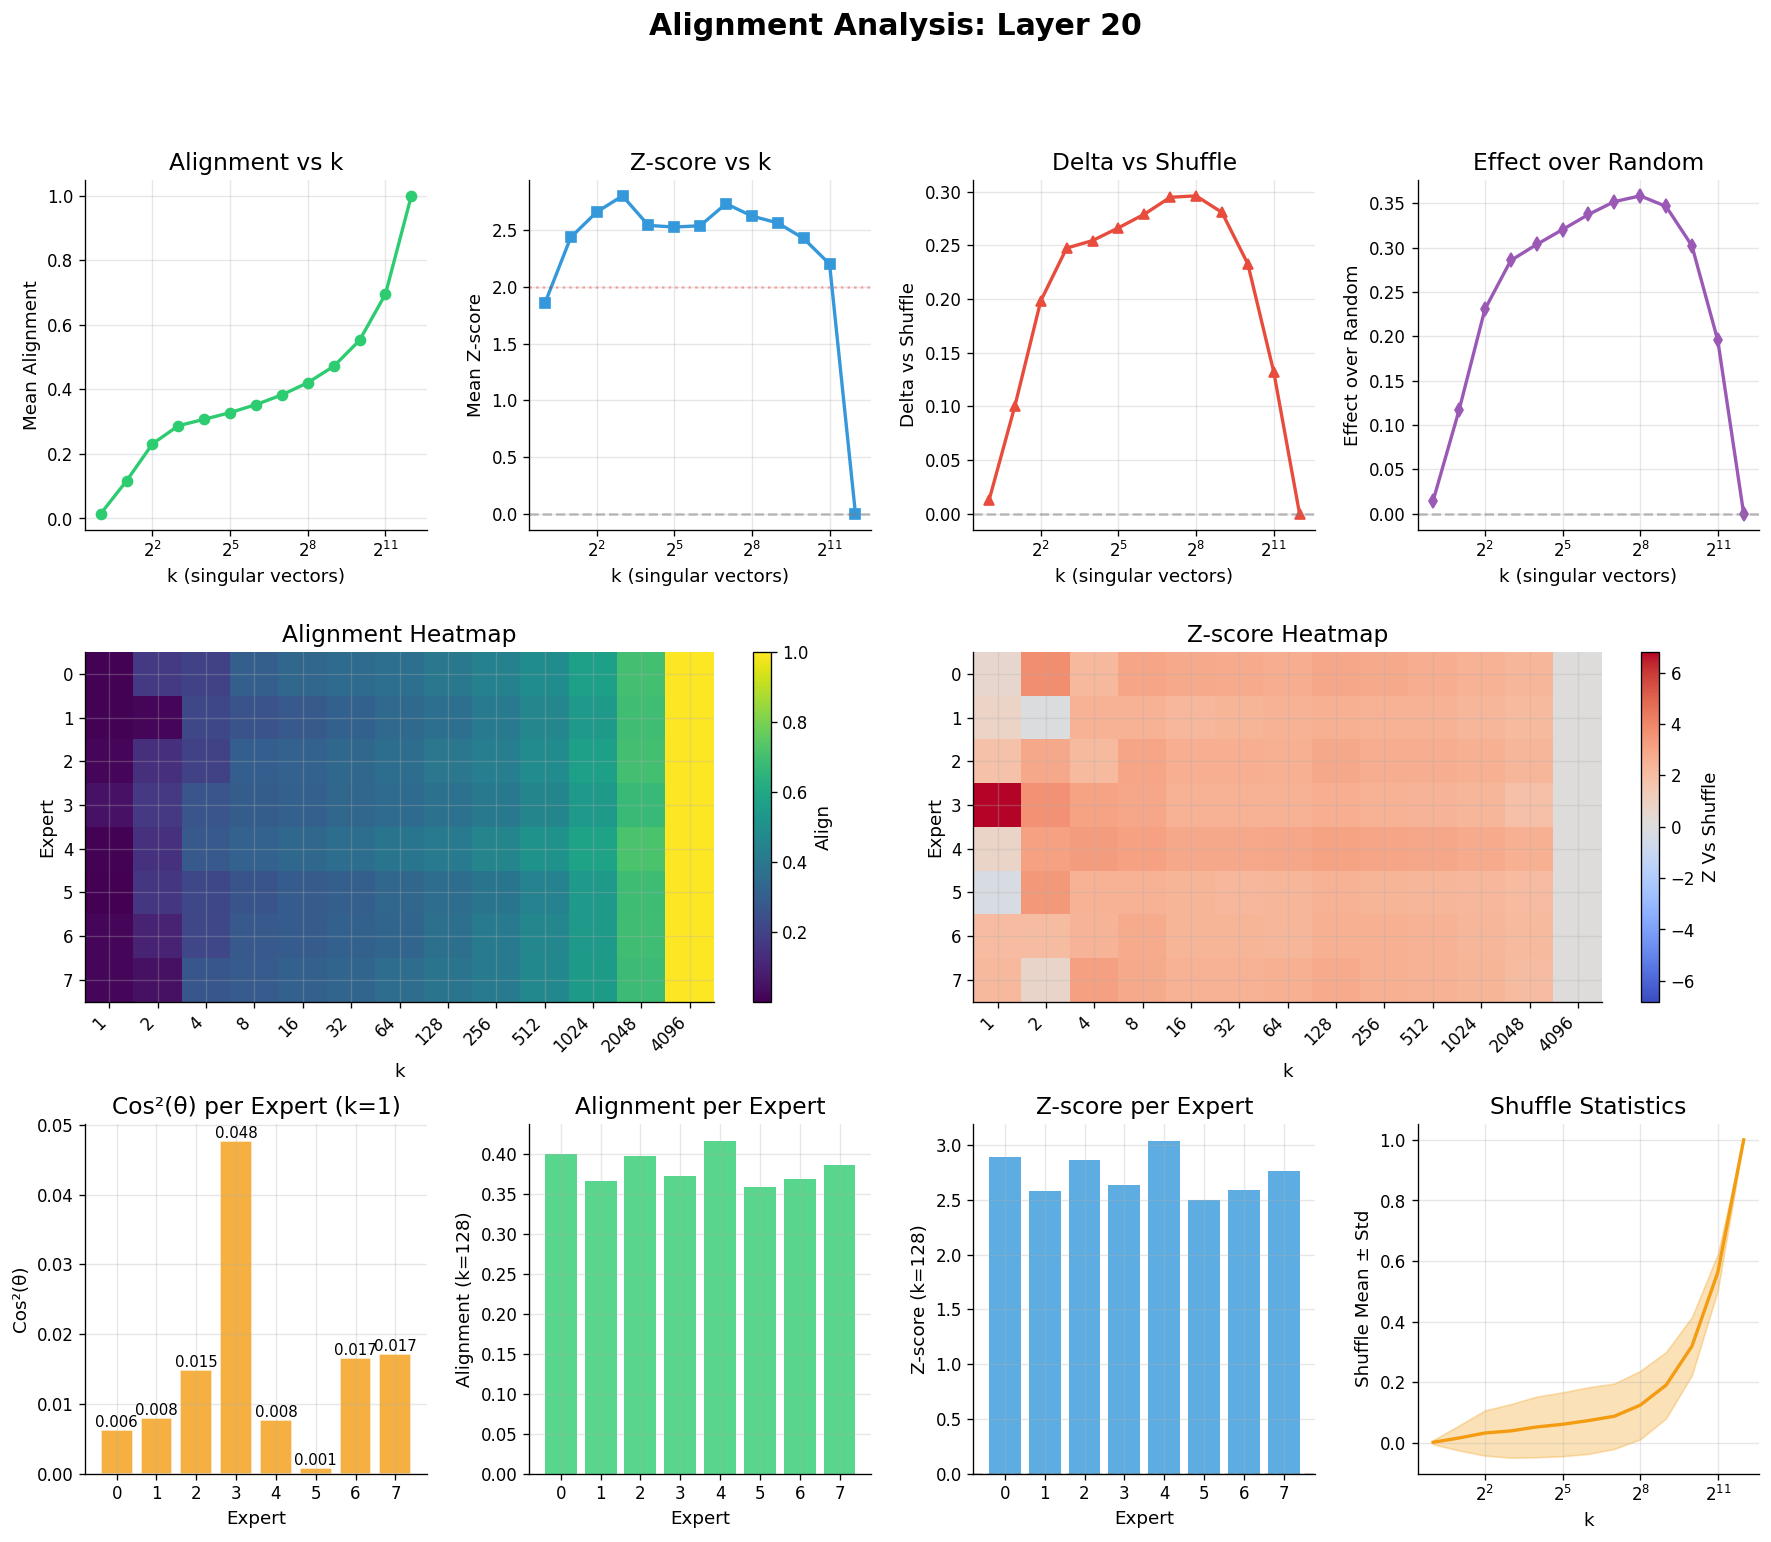

In [34]:
# Full analysis (12 subplots)
if result_file:
    plot_full_analysis(results, metadata)

## 5. Compare Multiple Layers

Load and compare results from different layers.

Available layers: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]
  Layer 1: layer1_svd_k1-4096-13_shuffles200_seed42_20260207_151446.json
  Layer 9: layer9_svd_k1-4096-13_shuffles500_seed42_20260207_145139.json
  Layer 16: layer16_svd_k1-4096-13_shuffles200_seed42_20260207_151745.json
  Layer 25: layer25_svd_k1-4096-13_shuffles200_seed42_20260207_151935.json
  Layer 27: layer27_svd_k1-4096-13_shuffles200_seed42_20260207_151959.json
  Layer 29: layer29_svd_k1-4096-13_shuffles200_seed42_20260207_152022.json


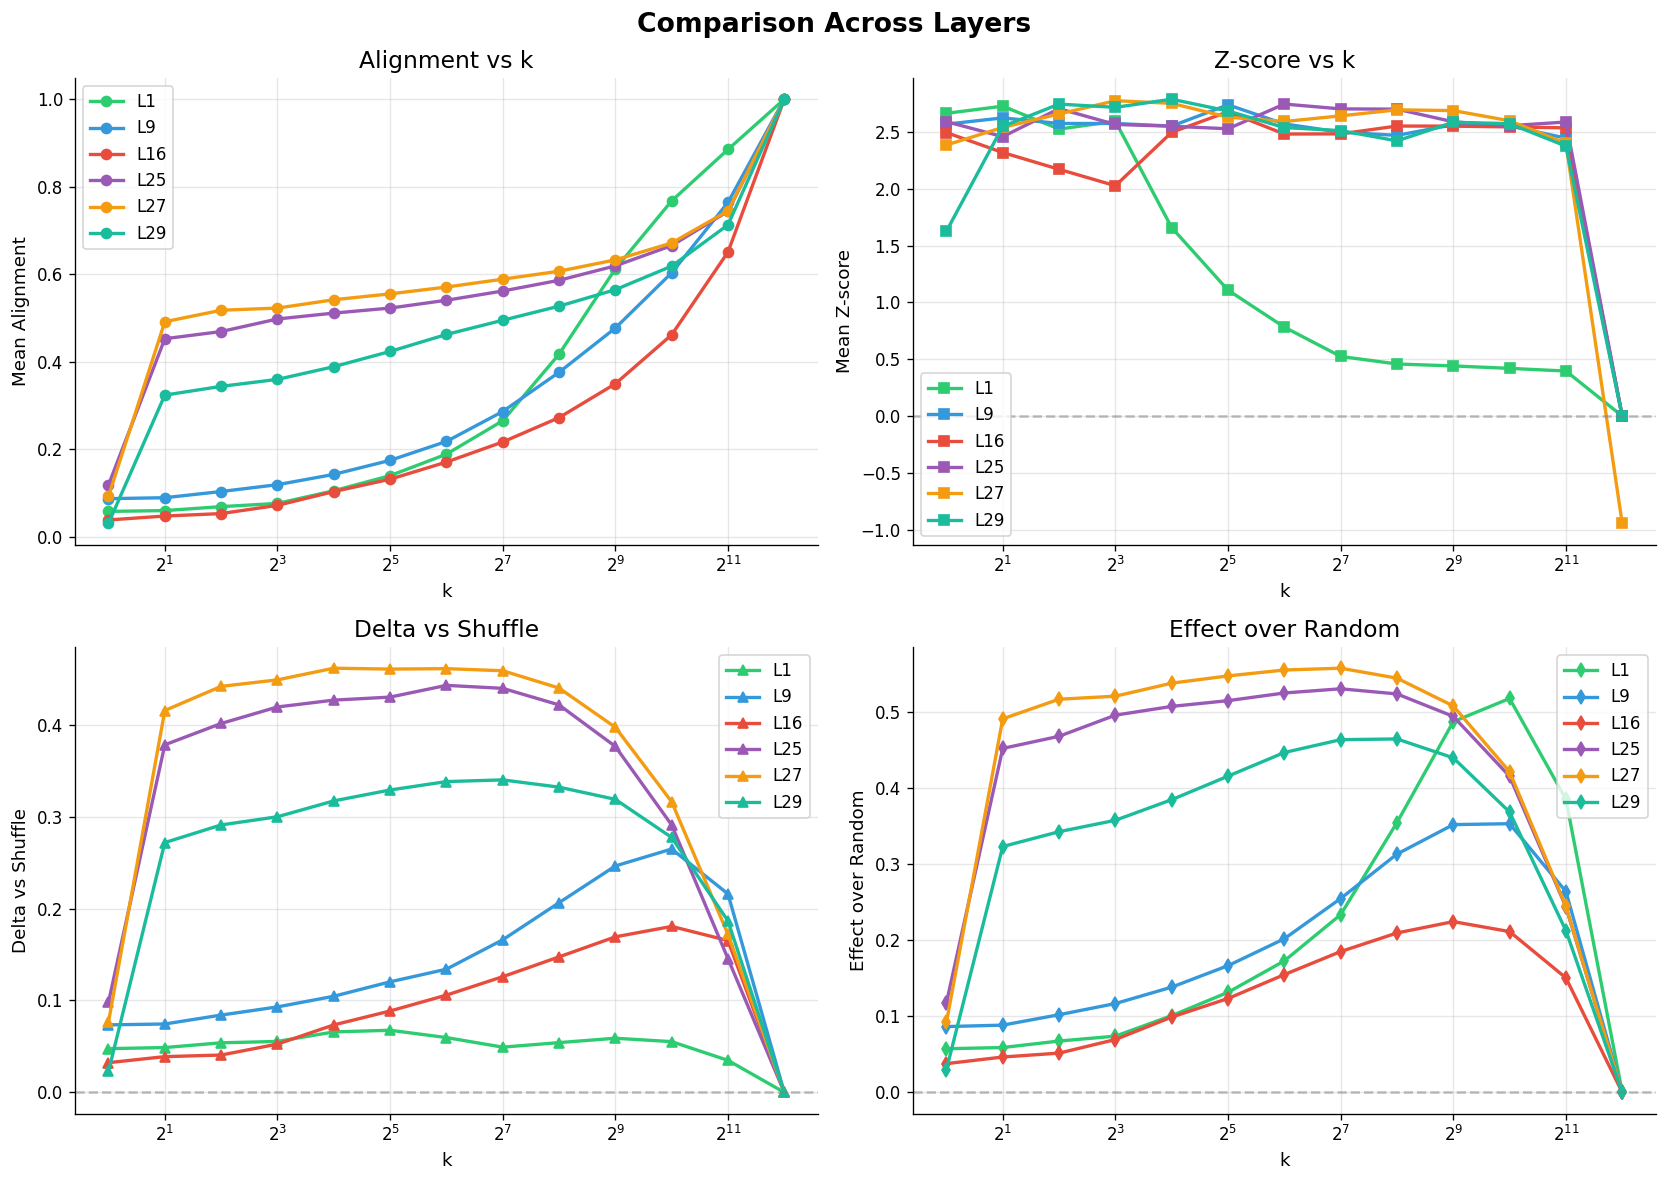

In [73]:
import re

# Build mapping: layer number -> most recent result file
layer_to_file = {}
for f in result_files:
    m = re.search(r'layer(\d+)_', f.name)
    if m:
        layer_to_file[int(m.group(1))] = f

print(f"Available layers: {sorted(layer_to_file.keys())}")

HIGH_ALIGNMENT_LAYERS = [20,21,22,24,25,26,27,28,29,30]
GOOD_ALIGNMENT_LAYERS = [15,16,17,18,19]
MID_ALIGNMENT_LAYERS = [2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18]
LOW_ALIGNMENT_LAYERS = [0,1,31]
# ===== Choose which layers to compare =====
layers_to_compare = [1, 9,16,25,27,29]
# layers_to_compare = sorted(layer_to_file.keys())  # all layers
# ===========================================
runs = []
for layer in sorted(layers_to_compare):
    if layer in layer_to_file:
        meta, res = load_results(str(layer_to_file[layer]))
        runs.append((meta, res))
        print(f"  Layer {layer}: {layer_to_file[layer].name}")
    else:
        print(f"  Layer {layer}: NOT FOUND, skipping")

if len(runs) >= 2:
    plot_comparison(runs)
else:
    print("Need at least 2 layers for comparison.")

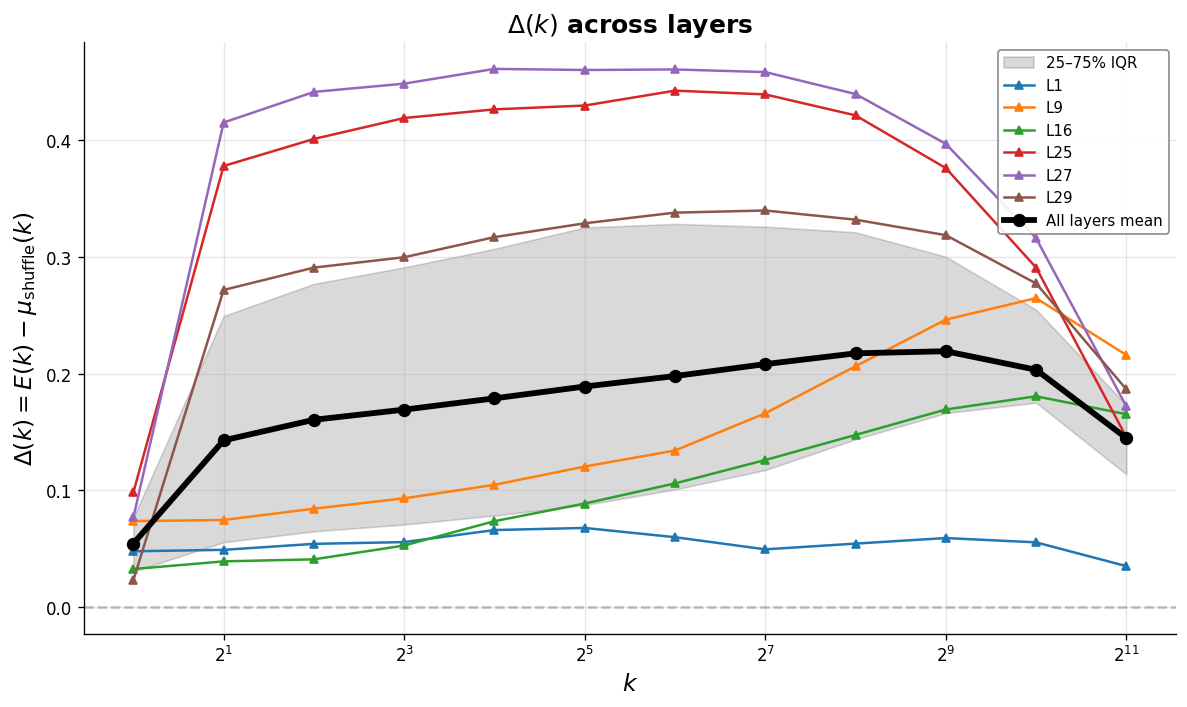

In [74]:
# Single plot: Delta vs Shuffle for selected layers
import matplotlib.pyplot as plt
from src.alignment_analysis import AlignmentResult

fig, ax = plt.subplots(figsize=(10, 6))

# Load all layers and compute stats
all_dfs = []
for layer in sorted(layer_to_file.keys()):
    m, r = load_results(str(layer_to_file[layer]))
    all_dfs.append(AlignmentResult.to_dataframe(r))
all_df = pd.concat(all_dfs, ignore_index=True)

# Drop k=4096 (Delta=0 by construction)
all_df = all_df[all_df["k"] < 4096]

# Per-layer means, then stats across layers
layer_means = all_df.groupby(["layer", "k"])["delta_vs_shuffle"].mean().unstack("layer")
global_mean = layer_means.mean(axis=1)
q25 = layer_means.quantile(0.25, axis=1)
q75 = layer_means.quantile(0.75, axis=1)

# IQR band
ax.fill_between(global_mean.index, q25.values, q75.values,
                color="black", alpha=0.15, label="25–75% IQR")

# Selected layer curves (thinner)
for i, (meta, res) in enumerate(runs):
    df_run = AlignmentResult.to_dataframe(res)
    df_run = df_run[df_run["k"] < 4096]
    summary = df_run.groupby("k")["delta_vs_shuffle"].mean()
    ax.plot(summary.index, summary.values, marker="^", linewidth=1.5,
            markersize=5, label=meta.layer_label)

# Mean line (thick, on top)
ax.plot(global_mean.index, global_mean.values, color="black", linewidth=3.5,
        marker="o", markersize=7, label="All layers mean", zorder=10)

ax.set_xscale("log", base=2)
ax.set_xlabel("$k$", fontsize=14)
ax.set_ylabel(r"$\Delta(k) = E(k) - \mu_{\mathrm{shuffle}}(k)$", fontsize=14)
ax.set_title(r"$\Delta(k)$ across layers", fontsize=15, fontweight="bold")
ax.axhline(y=0, color="gray", linestyle="--", alpha=0.5)
ax.grid(True, alpha=0.3)

ax.legend(fontsize=9, loc="upper right", framealpha=0.9, edgecolor="gray")
fig.tight_layout()
plt.show()

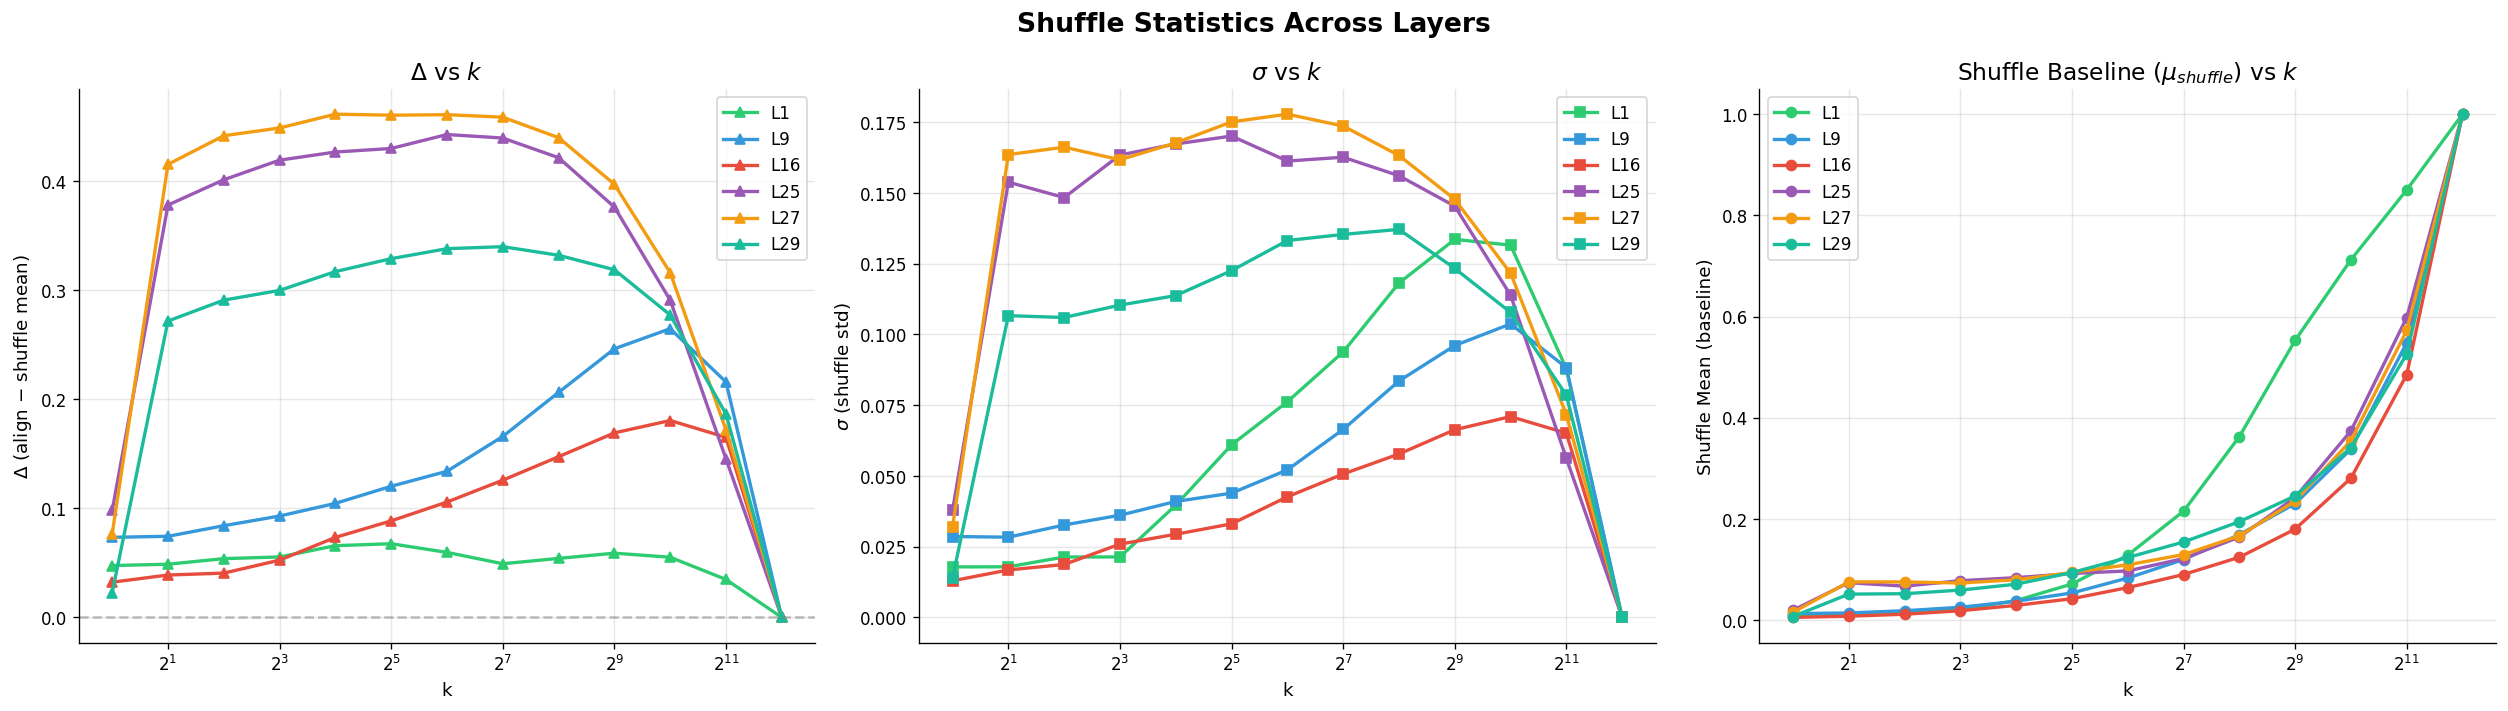

In [75]:
# Shuffle statistics comparison: Delta, Sigma, Baseline
from src.alignment_analysis import plot_shuffle_comparison

if len(runs) >= 2:
    plot_shuffle_comparison(runs)
else:
    print("Need at least 2 layers (run the cell above first).")

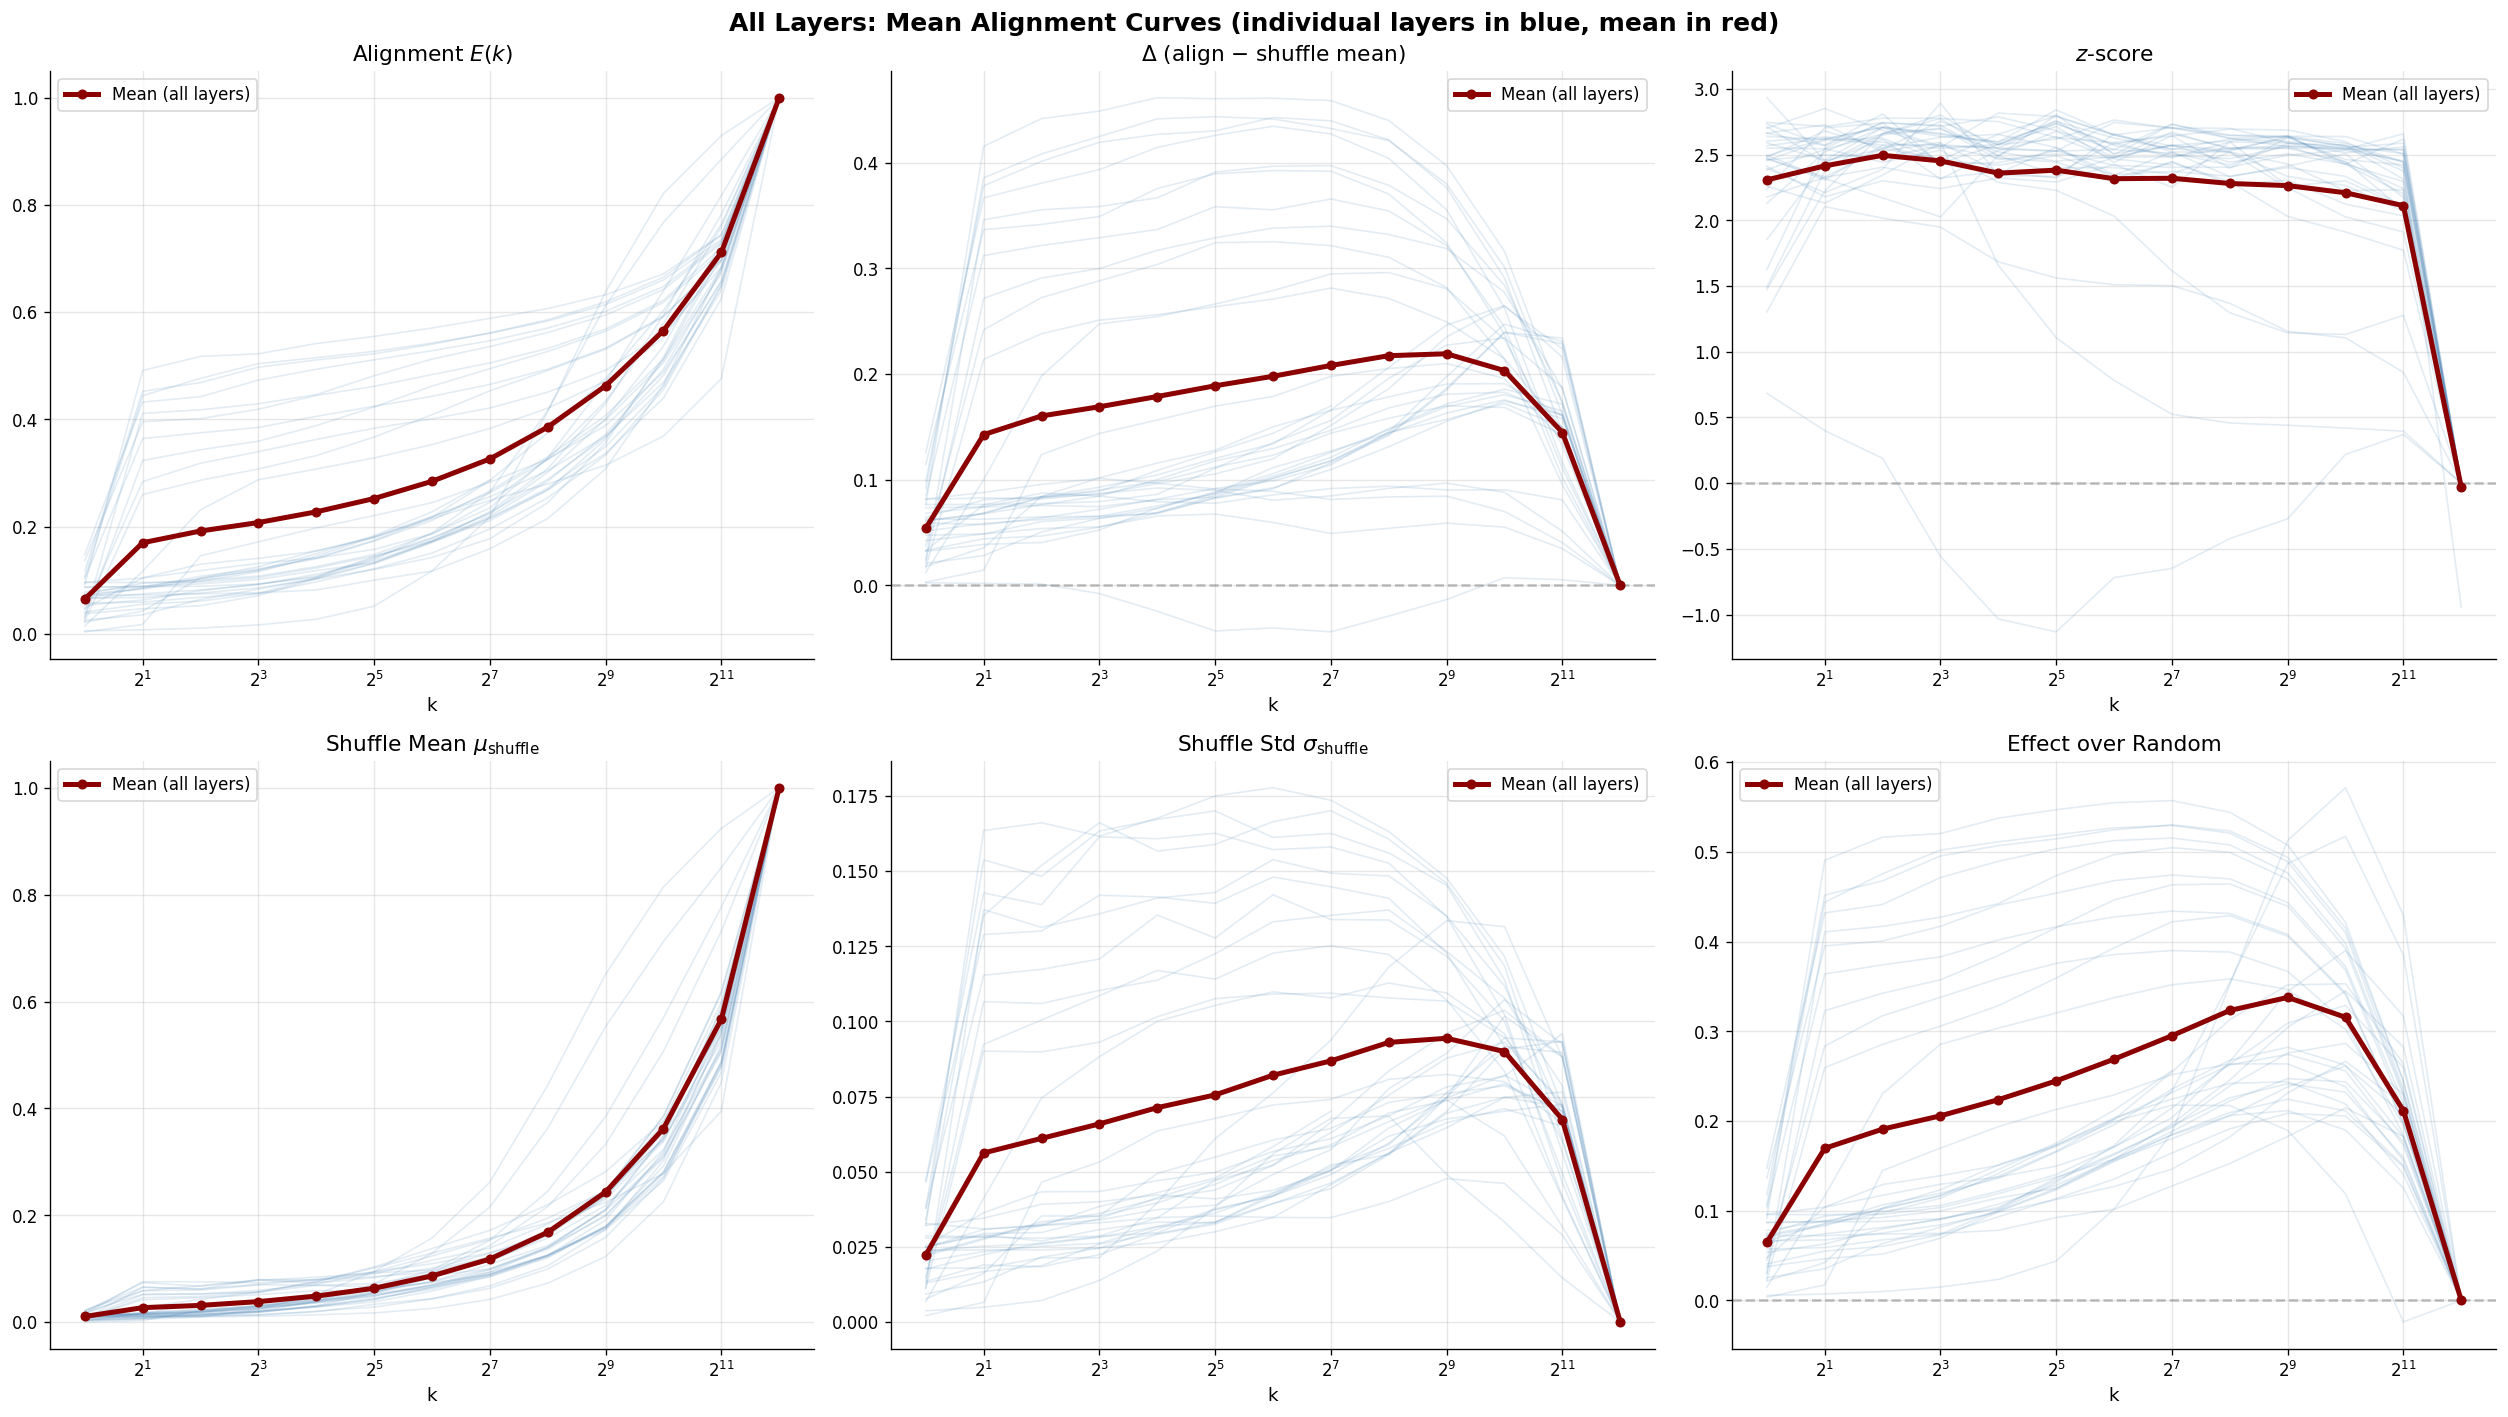


Loaded 32 layers.
Global mean z-score (across all k, all layers): 2.150


In [69]:
# ===== All-layers mean curves (with individual layers in background) =====
import matplotlib.pyplot as plt
import numpy as np

# Load ALL layers
all_runs = []
for layer in sorted(layer_to_file.keys()):
    meta, res = load_results(str(layer_to_file[layer]))
    all_runs.append((meta, res))

# Collect per-layer summaries into one big DataFrame
from src.alignment_analysis import AlignmentResult
all_dfs = []
for meta, res in all_runs:
    df_layer = AlignmentResult.to_dataframe(res)
    df_layer["layer_label"] = meta.layer_label
    all_dfs.append(df_layer)
all_df = pd.concat(all_dfs, ignore_index=True)

# Compute per-layer means and global mean
metrics = ["align", "delta_vs_shuffle", "z_vs_shuffle", "shuffle_mean", "shuffle_std", "effect_over_random"]
titles  = ["Alignment $E(k)$", r"$\Delta$ (align $-$ shuffle mean)", "$z$-score",
           r"Shuffle Mean $\mu_{\mathrm{shuffle}}$", r"Shuffle Std $\sigma_{\mathrm{shuffle}}$", "Effect over Random"]

fig, axes = plt.subplots(2, 3, figsize=(21, 12))
axes = axes.flat

for ax, metric, title in zip(axes, metrics, titles):
    # Individual layer curves (thin, transparent)
    for label, grp in all_df.groupby("layer_label"):
        layer_mean = grp.groupby("k")[metric].mean()
        ax.plot(layer_mean.index, layer_mean.values, color="steelblue", alpha=0.15, linewidth=1)

    # Global mean (thick, bold)
    global_mean = all_df.groupby("k")[metric].mean()
    ax.plot(global_mean.index, global_mean.values, color="darkred", linewidth=3, marker="o",
            markersize=5, label="Mean (all layers)", zorder=10)

    ax.set_xscale("log", base=2)
    ax.set_xlabel("k")
    ax.set_title(title, fontsize=13)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)

    # Reference line at y=0 where relevant
    if metric in ("delta_vs_shuffle", "z_vs_shuffle", "effect_over_random"):
        ax.axhline(y=0, color="gray", linestyle="--", alpha=0.5)

fig.suptitle("All Layers: Mean Alignment Curves (individual layers in blue, mean in red)",
             fontsize=15, fontweight="bold")
fig.tight_layout()
plt.show()

print(f"\nLoaded {len(all_runs)} layers.")
print(f"Global mean z-score (across all k, all layers): {all_df['z_vs_shuffle'].mean():.3f}")

## 6. Custom Plots

Individual plot functions for custom analysis.

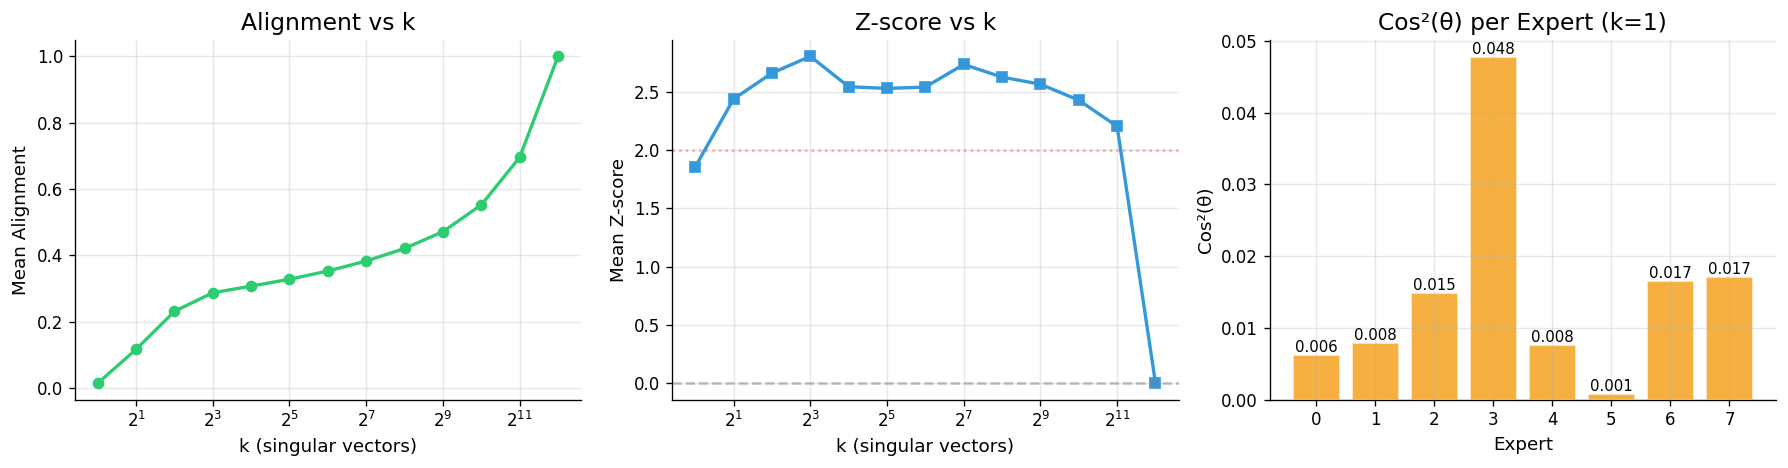

In [68]:
import matplotlib.pyplot as plt

if result_file:
    # Create custom figure with specific plots
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    plot_alignment_vs_k(results, ax=axes[0])
    plot_zscore_vs_k(results, ax=axes[1])
    plot_cos_squared_per_expert(results, ax=axes[2])
    
    plt.tight_layout()
    plt.show()

## 7. Save Plots

Save plots to files for reports.

In [38]:
from pathlib import Path

if result_file:
    # Create output directory
    plots_dir = Path("plots")
    plots_dir.mkdir(exist_ok=True)
    
    # Save summary plot
    save_path = plots_dir / f"summary_layer{metadata.layer}.png"
    plot_summary(results, save_path=save_path, show=False)
    print(f"Saved: {save_path}")
    
    # Save full analysis
    save_path = plots_dir / f"full_analysis_layer{metadata.layer}.png"
    plot_full_analysis(results, metadata, save_path=save_path, show=False)
    print(f"Saved: {save_path}")

Saved: plots/summary_layer20.png
Saved: plots/full_analysis_layer20.png
